# <h2 style="text-align:center;">Análisis exploratorio de datos (EDA) - Trabajo Final Python</h2>

## Pasos a seguir para realizar el EDA

1. Definición del problema
2. Recopilación de datos
3. Análisis descriptivo
4. Limpieza de datos
5. Análisis de variables (univariante, multivariante)
6. Ingeniería de características (Duplicados, faltantes, nuevas características)
7. Split
8. Scaling y encoding
9. Selección de características

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import model_selection

# split para modelado
from sklearn.model_selection import train_test_split

# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

# To save models
import json
import pickle

# Feature selection
from sklearn.feature_selection import f_classif, SelectKBest

import streamlit as st

# Paso 1: Definición del problema

El objetivo de este Análisis Exploratorio de Datos (EDA, por sus siglas en inglés) es estudiar los tiempos de tramitación de las solicitudes de derechos de uso de agua subterránea presentadas ante Dinagua, identificando los factores asociados a mayores demoras en las etapas técnica y registral. En particular, se buscará evaluar si el tipo de uso declarado influye en la duración del trámite, considerando que determinadas categorías, como el uso para riego, pueden requerir gestiones paralelas o autorizaciones adicionales ante otros organismos públicos, lo que podría impactar en los tiempos de resolución.e identificar

# Paso 2: Recopilación de datos
#### Dataset: Registro de solicitudes de uso de aguas subterráneas en el Sistema de Información Hídrica de Dinagua



La base de datos utilizada en este trabajo corresponde a la información disponible en el Sistema de Información Hídrica (SIH) de la Dirección Nacional de Aguas (Dinagua), dependiente del Ministerio de Ambiente de Uruguay. Este sistema centraliza y gestiona datos relacionados con los recursos hídricos del país, constituyendo una fuente oficial y confiable para el análisis de información vinculada al uso y aprovechamiento del agua.

Los registros empleados en este estudio fueron obtenidos a partir de las solicitudes de derechos de uso de agua subterránea presentadas ante Dinagua por particulares, empresas e instituciones. Estas solicitudes contienen información relevante sobre la localización de las captaciones, los volúmenes solicitados, los usos previstos del recurso y otras variables de interés para la gestión hídrica.

A partir de esta base de datos se desarrollará un EDA, utilizando herramientas de Python para examinar la estructura, calidad y distribución de la información.

A continuación se presenta un glosario de las variables incluidas en la base de datos a utilizar:

###### Diccionario de Datos / glosario

| Variable                          | Definición                                                                                                                                                                                                                | Tipo / Valores                                                 |
|:----------------------------------|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:---------------------------------------------------------------|
| **Tipo de Solicitud**             | Modalidad del trámite iniciado                                                                                                                                                                                            | Texto (ej: Proyecto de Aprovechamiento)                        |
| **Nro. GEX**                      | Número de expediente administrativo de gestión                                                                                                                                                                            | Texto                                                          |
| **Fecha de vencimiento**          | Vencimiento del derecho de uso de aguas públicas, máximo 10 años, pero depende del uso que se le va a dar al agua                                                                                                         | Texto                                                          |
| **Estado**                        | Situación actual del trámite ante Dinagua                                                                                                                                                                                 | Texto (ej: Registrada, Pendiente de Resolución, En estudio)    |
| **Regional**                      | Oficina regional de Dinagua dónde se realiza el trámite                                                                                                                                                                   | Texto (ej: Cerro Largo, Salto, Artigas)                        |
| **Departamento**                  | Ubicación de la perforación                                                                                                                                                                                               | Texto (ej: Salto, Paysandú)                                    |
| **Técnicos**                      | Profesional responsable del trámite ante Dinagua                                                                                                                                                                          | Texto                                                          |
| **Fecha de solicitud**            | Fecha de inicio de trámite ante Dinagua                                                                                                                                                                                   | Fecha                                                          |
| **Fecha de Resolución**           | Fecha de resolución del trámite ante Dinagua                                                                                                                                                                              | Fecha                                                          |
| **Fecha de Inscripción**          | Fecha de incripción del otorgamiento del derecho de uso en el registro público                                                                                                                                            | Fecha                                                          |
| **Caudal**                        | Caudal solicitado o aprobado en metrós cúbicos sobre hora                                                                                                                                                                 | Número decimal                                                 |
| **Volumen**                       | Volumen anual de extracción de agua expresado en metrós cúbicos. Se calcula multiplicando el caudal de la perforación, por la cantidad de horas de uso diario, por los días en el mes, por la cantidad de meses en el año | Número entero                                                  |
| **Uso**                           | Clasificación general de cuál es el uso que se le va a dar al agua que se extrae                                                                                                                                          | Texto (ej: Otros usos agropecuarios, consumo humano)
| **Destino**                       | Subcategoría de uso. Finalidad específica del agua que se extrae                                                                                                                                                          | Texto (ej: Abrevadero de ganado, abastecimiento a poblaciones)
| **Latitud**                       | Ubicación de la perforación                                                                                                                                                                                               | Número decimal                                                 |
| **Longitud**                      | Ubicación de la perforación                                                                                                                                                                                               | Número decimal                                                 |
| **Mes Inicio**                    | En qué mes del año se comienza con la extracción de agua                                                                                                                                                                  | Texto                                                          |
| **Mes Final**                     | En qué mes del año se finaliza con la extracción de agua                                                                                                                                                                  | Texto                                                          |
| **Horas x Año**                   | Cantidad de horas anuales de extracción de agua                                                                                                                                                                           | Número entero                                                  |
| **Depto.-Padrón**                 | Padrón y departamento de bicación de la perforación                                                                                                                                                                       | Texto y número entero                                          |
 | **Tipo de Obra**                  | En este caso el único tipo de obra es perforación                                                                                                                                                                         | Texto                                                          |
| **Id Solicitud**                  | Identificador único                                                                                                                                                                                                       | Número entero                                                  |
| **Sección y localidad catastral** | Sección y localidad catastral a la que pertenece el padrón                                                                                                                                                                | Número entero                                                  |
| **Tipo de acuifero**              | Acuífero desde donde se obtiene el agua subterránea a extraer                                                                                                                                                             | Texto (ej.: fisurado, sedimentario, ambos)                     |
| **Profundidad**                   | Profundidad en metros de la perforación                                                                                                                                                                                   | Número decimal                                                 |
| **Diámetro**                      | Diamétro en metros de la perforación                                                                                                                                                                                      | Número decimal                                                 |
| **Caudal Ensayado**               | Caudal obtenido en el momento del ensayo de bombeo expresado en metros cúbicos                                                                                                                                            | Número decimal                                                 |
| **Nivel Estático**                | A que profundidad está el agua cuando el pozo no es utilizado por un perìodo mayor a 8 horas, en relación al 0 que es la superficie                                                                                       | Número decimal                                                 |
| **Nivel Dinámico**                | A que profundidad está el agua cuando el pozo está en uso, en relación al 0 que es la superficie                                                                                                                          | Número decimal                                                 |



Observación: los datos descargados desde el Sistema de Información Hídrica de Dinagua se obtienen en un excel tipo sábana, donde figuran varias columnas vacías que en casos como las perforaciones, no aportan información. Por ejemplo: cuencas hidrográficas, curso a utilizar, producción, entre otras.

A continuación se procede a importar los datos y crear el DataFrame:

In [14]:
# Carga de datos
df = pd.read_csv("../data/raw/Base_datos.csv")

# Mostrar datos
df

,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Caudal Máximo,Codigo Cuencas de nivel 2,Accion Solicitud,Tipo Resolución,Producción
0,Proyecto de Aprovechamiento,SGRH-00040200289-635.001,27/Mar/2011,Registrada,SALTO,SALTO,"Rodríguez, Jorge",18/Sep/2000,27/Mar/2001,NaN,...,55.0,0.15,19.7,20.0,37.50,NaN,14.0,Nueva,Autorización,7.0
1,Proyecto de Aprovechamiento,SGRH-00040200324-595.001,19/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,19/Oct/2000,25/Oct/2000,...,53.0,0.15,9.0,25.0,29.00,NaN,18.0,Nueva,Autorización,4.0
2,Proyecto de Aprovechamiento,SGRH-00040200325-596.001,20/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,20/Oct/2000,27/Oct/2000,...,31.0,0.15,25.0,2.0,5.00,NaN,18.0,Nueva,Autorización,4.0
3,Proyecto de Aprovechamiento,SGRH-00040200402-598.001,19/Oct/2010,Registrada,SAN JOSÉ,SAN JOSÉ,"Rodríguez, Jorge",11/Apr/2000,19/Oct/2000,25/Oct/2000,...,55.0,0.15,20.0,28.0,32.50,NaN,24.0,Nueva,Autorización,2.5
4,Proyecto de Aprovechamiento,SGRH-00040200414-609.001,10/Oct/2010,Registrada,SAN JOSÉ,CANELONES,"Rodríguez, Jorge",14/Apr/2000,10/Oct/2000,18/Oct/2000,...,64.0,0.15,6.8,3.9,22.30,NaN,63.0,Nueva,Autorización,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5154,Proyecto de Aprovechamiento,2026/36001/003138,NaN,En Estudio,DURAZNO,FLORES,MARGARITA MARÍA SIENRA VALLE,23/Mar/2026,NaN,NaN,...,35.0,150.00,8.0,3.2,4.65,NaN,57.0,Nueva,NaN,0.0
5155,Proyecto de Aprovechamiento,2026/36001/003236,NaN,En Estudio,FRAY BENTOS,PAYSANDÚ,ALEJANDRO LEONEL SCHIPILOV ZACCHINO,24/Mar/2026,NaN,NaN,...,48.0,160.00,7.0,5.0,17.00,NaN,18.0,Nueva,NaN,0.0
5156,Proyecto de Aprovechamiento,2026/36001/003447,NaN,En Estudio,FRAY BENTOS,COLONIA,Gustavo Norberto Galmarini Silva,6/Apr/2026,NaN,NaN,...,33.0,150.00,2.5,6.0,25.00,NaN,23.0,Nueva,NaN,0.0
5157,Proyecto de Aprovechamiento,2026/36001/003411,NaN,En Estudio,SALTO,SALTO,ALEJANDRO LEONEL SCHIPILOV ZACCHINO,27/Mar/2026,NaN,NaN,...,61.0,160.00,7.0,6.5,18.00,NaN,13.0,Renov/Modif,NaN,0.0


# Paso 3: Análisis descriptivo:

Una vez cargado el conjunto de datos, se debe analizarlo en su totalidad para obtener conclusiones conjuntas. Una vez que se tiene la información cargada en una estructura de datos manejable como es un DataFrame de Pandas, se puede arrancar con el proceso.

In [15]:
# Visualizar el tamaño del DataFrame:

df.shape

(5159, 38)

In [16]:
# Obtener información sobre tipos de datos y valores no nulos del DataFrame:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5159 entries, 0 to 5158
Data columns (total 38 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Tipo de Solicitud              5159 non-null   str    
 1   Nro. GEX                       5157 non-null   str    
 2   Fecha Vencimiento              4700 non-null   str    
 3   Estado                         5159 non-null   str    
 4   Regional                       5157 non-null   str    
 5   Departamento                   5157 non-null   str    
 6   Tecnicos                       5142 non-null   str    
 7   Fecha de Solicitud             5158 non-null   str    
 8   Fecha de Resolución            4699 non-null   str    
 9   Fecha de Inscripción           4653 non-null   str    
 10  Caudal                         5113 non-null   float64
 11  Volumen                        5127 non-null   float64
 12  Uso                            5159 non-null   str    
 13 

In [17]:
# Resumen estadístico rápido de las columnas numéricas deL DataFrame:
df.describe()

,Caudal,Volumen,Longitud,Mes Inicio,Mes Final,Horas x Año,Id Solicitud,Codigo Cuencas de nivel 5,Sección y localidad catastral,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Caudal Máximo,Codigo Cuencas de nivel 2,Producción
count,5113.000000,5.127000e+03,5.159000e+03,5123.000000,5123.000000,5121.000000,5159.000000,5152.000000,3387.000000,5115.000000,5095.000000,4972.000000,4808.000000,4655.000000,0.0,5152.000000,1.802000e+03
mean,30.760613,3.103822e+04,1.330911e+04,6.718915,9.740582,3128.130443,249482.421012,37711.344332,5.623561,52.235572,173.100473,16.159835,10.636425,26.939966,NaN,37.194682,9.611563e+02
std,710.006984,6.766600e+04,1.140227e+05,5.342711,3.386649,1866.384298,6255.075576,18888.650444,13.541791,65.214100,225.025282,245.645150,19.967036,23.805388,NaN,18.909617,2.625827e+04
min,0.000000,0.000000e+00,-5.841575e+01,1.000000,0.000000,1.000000,237902.000000,10105.000000,0.000000,0.000000,0.000000,0.000000,-9.550000,-39.620000,NaN,10.000000,0.000000e+00
25%,2.500000,5.184000e+03,-5.741145e+01,1.000000,10.000000,1600.000000,244274.500000,22600.000000,2.000000,35.000000,150.000000,2.800000,4.620000,16.000000,NaN,22.000000,0.000000e+00
50%,5.000000,1.296000e+04,-5.635150e+01,10.000000,11.000000,2880.000000,249362.000000,27400.000000,4.000000,45.000000,160.000000,5.500000,8.700000,24.000000,NaN,27.000000,1.000000e+00
75%,10.000000,3.024000e+04,-5.596010e+01,12.000000,12.000000,4320.000000,254852.500000,58171.250000,7.000000,60.000000,200.000000,12.000000,14.000000,35.000000,NaN,58.000000,5.000000e+00
max,27000.000000,1.814400e+06,6.237718e+06,12.000000,12.000000,9000.000000,261225.000000,68710.000000,746.000000,1494.000000,5000.000000,15000.000000,1234.000000,1234.000000,NaN,68.000000,1.095000e+06


> ##### Observaciones:
>
> Una vez obtenida esta información, se extraen las siguientes conclusiones:
>
> * Existen un total de 5159 filas, que se corresponde con 5159 solicitudes de derechos de uso de agua subterránea ante Dinagua
> * Existen un total de 38 columnas que contienen diferentes datos obtenidos a partir de cada solicitud de derecho de uso de agua
> * Todas las solicitudes tienen un número de expediente asociado
> * La columna Fecha de vencimiento tiene un total de 4700. La diferencia con el total corresponde a que varias solicitudes se encuentran en estudio o pendientes de resolución.
> * Hay dos solicitudes que no tienen una oficina Regional y Departamento asociado. Es necesario corregirlo a partir de su ubicación.
> * La columna que contiene los nombres de los técnicos actuantes tiene algunos datos faltantes, pero en principio la información no es de utilidad.
> * Las columnas que contienen fechas, como fecha de solicitud, resolución, incripción, permiten estudiar la demora que tienen los trámites de este tipo en Dinagua. Aquellas columnas sin fecha de resolución y/o incripción, son aquellas en estudio o pendientes de resolución.
> * Las columnas que carecen de datos de caudal y/o volumen pueden corresponderse con solicitudes de permiso de estudio. En estos casos, dicha información no siempre es requerida.
> * Es necesario obtener de la columna Depto.-Padrón los datos de padrón y eliminar los datos de Departamentos, ya que esa información está en otra columna.
> * Las siguientes columnas no aportarían información y deberían ser borradas:
>   * Columna Documento: el objetivo de ser borrada es anonimizar los datos
>   * Columnas que contienen información sobre cuencas hidrográficas: están por defecto, pero son datos que no se relacionan con los acuíferos, no aportan información de utilidad.
>   * Columna Curso a utilizar: idem explicación anterior.
>   * Columna Producción: tiene muchos datos vacíos, no aporta información de utilidad.
>   * Columna Tipo de Obra: para este caso todas las obras son "pozos", no aporta información de utilidad.


# Paso 4: Limpieza de datos

###### 4.1 Limpieza de datos: eliminar duplicados para evitar errores.

In [18]:
# Busqueda de valores duplicados:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
5154    False
5155    False
5156    False
5157    False
5158    False
Length: 5159, dtype: bool

In [19]:
# Se suman los valores duplicados. En el caso de existir, el resultado de la suma debería ser mayor a 1:
df.duplicated().sum()

np.int64(0)

En este caso no se encontraron valores duplicados.

###### 4.2 Limpieza de datos: eliminar información irrelevante y columnas vacías

>   * Debemos hacernos la siguiente pregunta: ¿todos los datos son de utilidad?
>   * La respuesta a esta pregunta es no. Por tal procedere a realizar las siguientes modificaciones de mi DataFrame:

A partir de df.info() observamos que la columna "Caudal Máximo" se encuentra vacía, por lo cual se procederá a borrarla:

In [20]:
# Eliminar columnas vacías
df.drop(columns=['Caudal Máximo'], inplace=True)

# Ver primeras filas de la base de datos para corroborar que la columna "Caudal Máximo" fue borrada correctamente
df.head()

,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,Tipo de acuifero,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Codigo Cuencas de nivel 2,Accion Solicitud,Tipo Resolución,Producción
0,Proyecto de Aprovechamiento,SGRH-00040200289-635.001,27/Mar/2011,Registrada,SALTO,SALTO,"Rodríguez, Jorge",18/Sep/2000,27/Mar/2001,NaN,...,NaN,55.0,0.15,19.7,20.0,37.5,14.0,Nueva,Autorización,7.0
1,Proyecto de Aprovechamiento,SGRH-00040200324-595.001,19/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,19/Oct/2000,25/Oct/2000,...,NaN,53.0,0.15,9.0,25.0,29.0,18.0,Nueva,Autorización,4.0
2,Proyecto de Aprovechamiento,SGRH-00040200325-596.001,20/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,20/Oct/2000,27/Oct/2000,...,NaN,31.0,0.15,25.0,2.0,5.0,18.0,Nueva,Autorización,4.0
3,Proyecto de Aprovechamiento,SGRH-00040200402-598.001,19/Oct/2010,Registrada,SAN JOSÉ,SAN JOSÉ,"Rodríguez, Jorge",11/Apr/2000,19/Oct/2000,25/Oct/2000,...,NaN,55.0,0.15,20.0,28.0,32.5,24.0,Nueva,Autorización,2.5
4,Proyecto de Aprovechamiento,SGRH-00040200414-609.001,10/Oct/2010,Registrada,SAN JOSÉ,CANELONES,"Rodríguez, Jorge",14/Apr/2000,10/Oct/2000,18/Oct/2000,...,NaN,64.0,0.15,6.8,3.9,22.3,63.0,Nueva,Autorización,6.0


Como fue mencionado anteriormente, se procederá a borrar las columnas que no aportan información. Como ser:

1. Columna Documento: el objetivo de ser borrada es anonimizar los datos
2. Columnas que contienen información sobre cuencas hidrográficas: están por defecto, pero son datos que no se relacionan con los acuíferos, no aportan información de utilidad.
3. Columna Curso a utilizar: idem explicación anterior.
4. Columna Producción: tiene muchos datos vacíos, no aporta información de utilidad.
5. Columna Tipo de Obra: para este caso todas las obras son "pozos", no aporta información de utilidad.

In [21]:
# Definición de la lista con los nombres exactos de las columnas a eliminar:
columnas_a_borrar = ['Documento', 'Codigo Cuencas de nivel 5', 'Codigo Cuencas de nivel 2', 'Cuencas de nivel 3', 'Curso a Utilizar', 'Producción', 'Tipo de Obra']

# Serán borradas todas juntas. Se utiliza errors='ignore' para evtar errores
df.drop(columns=columnas_a_borrar, inplace=True, errors='ignore')

# Verificar el nuevo tamaño de la base de datos para ver cuántas columnas quedaron conformando el DataFrame:
df.shape

(5159, 30)

Se borrara la columna Depto.-Padrón. Pero primero, para obtener una columna de padrones de ubicación de las perforaciones, es necesario separar la columna Depto-padron, así como borrar la columna departamentos que quede repetida. Para ello se harán las siguientes modificaciones:

In [22]:
# Separar por el guion y quedarse con la segunda parte de la informaciñon (posición 1, que es el número)
# Usar expand=True para que lo trate como una columna
padrón_puro = df['Depto.-Padrón'].str.split('-', expand=True)[1]

# Convertir a formato numérico la columna resultante en el paso anterior
padrón_numérico = pd.to_numeric(padrón_puro, errors='coerce')

# Redondear a 0 todos los valores y convertir los datos a tipo número entero Int64
df['Número de Padrón'] = padrón_numérico.round(0).astype('Int64')

# Borrar la columna combinada vieja ya que ya se cuenta con una columna de departamentos y ahora de padrones
df.drop(columns=['Depto.-Padrón'], inplace=True)

# Verificar que la columna nueva se haya creado y ver sus primeras filas
df.head()

,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,Sección y localidad catastral,Tipo de acuifero,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Accion Solicitud,Tipo Resolución,Número de Padrón
0,Proyecto de Aprovechamiento,SGRH-00040200289-635.001,27/Mar/2011,Registrada,SALTO,SALTO,"Rodríguez, Jorge",18/Sep/2000,27/Mar/2001,NaN,...,2.0,NaN,55.0,0.15,19.7,20.0,37.5,Nueva,Autorización,4739
1,Proyecto de Aprovechamiento,SGRH-00040200324-595.001,19/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,19/Oct/2000,25/Oct/2000,...,2.0,NaN,53.0,0.15,9.0,25.0,29.0,Nueva,Autorización,5331
2,Proyecto de Aprovechamiento,SGRH-00040200325-596.001,20/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,20/Oct/2000,27/Oct/2000,...,2.0,NaN,31.0,0.15,25.0,2.0,5.0,Nueva,Autorización,2048
3,Proyecto de Aprovechamiento,SGRH-00040200402-598.001,19/Oct/2010,Registrada,SAN JOSÉ,SAN JOSÉ,"Rodríguez, Jorge",11/Apr/2000,19/Oct/2000,25/Oct/2000,...,6.0,NaN,55.0,0.15,20.0,28.0,32.5,Nueva,Autorización,14232
4,Proyecto de Aprovechamiento,SGRH-00040200414-609.001,10/Oct/2010,Registrada,SAN JOSÉ,CANELONES,"Rodríguez, Jorge",14/Apr/2000,10/Oct/2000,18/Oct/2000,...,1.0,NaN,64.0,0.15,6.8,3.9,22.3,Nueva,Autorización,19


###### 4.3 Limpieza de datos: verificar que los datos tengan el formato correcto

Ahora se debe resolver un siguiente problema: convertir las columnas de fechas de tipo texto (str) a formato fecha (date). Según el glosario presentado en el primer paso hay cuatro columnas con datos de fecha:

- Fecha vencimiento
- Fecha de solicitud
- Fecha de resolución
- Fecha de incripción

In [23]:
# Columnas a cambiar de formato:
columnas_fechas = ['Fecha Vencimiento', 'Fecha de Solicitud', 'Fecha de Resolución', 'Fecha de Inscripción']

# Convertir todas a formato fecha de Python
for col in columnas_fechas:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Verificar si cambió el tipo de dato de esas columnas
df[columnas_fechas].dtypes

Fecha Vencimiento       datetime64[us]
Fecha de Solicitud      datetime64[us]
Fecha de Resolución     datetime64[us]
Fecha de Inscripción    datetime64[us]
dtype: object

La columna de datos "Latitud" está como tipo texto (str), hay que pasarlo a tipo decimal (float64):

In [24]:
# Convertir Latitud a formato numérico (float64)
df['Latitud'] = pd.to_numeric(df['Latitud'], errors='coerce')

# Verificar que ambas columnas de coordenadas (latitud y longitud) hayan quedado como con formato numérico decimal (float64)
df[['Latitud', 'Longitud']].dtypes

Latitud     float64
Longitud    float64
dtype: object

Nota: la función errors='coerce' convierte aquellas filas con errores en un valor vacío.

In [25]:
# Contar cuántos valores vacíos quedaron en las coordenadas
df[['Latitud', 'Longitud']].isna().sum()

Latitud     1
Longitud    0
dtype: int64

Las columnas Volumen y Horas x Año deben tener un formato tipo número decimal entero. Para ello se harán las siguientes modificaciones:

In [26]:
# Convertir a formato numérico primero (quedan como float64 si tienen decimales)
volumen_numeric = pd.to_numeric(df['Volumen'], errors='coerce')
horas_numeric = pd.to_numeric(df['Horas x Año'], errors='coerce')

# Redondear a 0 decimales y convertir a entero Int64
df['Volumen'] = volumen_numeric.round(0).astype('Int64')
df['Horas x Año'] = horas_numeric.round(0).astype('Int64')

# Verificar los formatos requeridos:
df[['Volumen', 'Horas x Año']].dtypes

Volumen        Int64
Horas x Año    Int64
dtype: object

In [27]:
# Volver a chequear la información del DataFrame a partir de las modificaciones realizadas:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5159 entries, 0 to 5158
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Tipo de Solicitud              5159 non-null   str           
 1   Nro. GEX                       5157 non-null   str           
 2   Fecha Vencimiento              4685 non-null   datetime64[us]
 3   Estado                         5159 non-null   str           
 4   Regional                       5157 non-null   str           
 5   Departamento                   5157 non-null   str           
 6   Tecnicos                       5142 non-null   str           
 7   Fecha de Solicitud             5158 non-null   datetime64[us]
 8   Fecha de Resolución            4699 non-null   datetime64[us]
 9   Fecha de Inscripción           4653 non-null   datetime64[us]
 10  Caudal                         5113 non-null   float64       
 11  Volumen                     

In [28]:
# Visualizar el encabezado del DataFrame

df

,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,Sección y localidad catastral,Tipo de acuifero,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Accion Solicitud,Tipo Resolución,Número de Padrón
0,Proyecto de Aprovechamiento,SGRH-00040200289-635.001,2011-03-27,Registrada,SALTO,SALTO,"Rodríguez, Jorge",2000-09-18,2001-03-27,NaT,...,2.0,NaN,55.0,0.15,19.7,20.0,37.50,Nueva,Autorización,4739
1,Proyecto de Aprovechamiento,SGRH-00040200324-595.001,2010-10-19,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",2000-03-10,2000-10-19,2000-10-25,...,2.0,NaN,53.0,0.15,9.0,25.0,29.00,Nueva,Autorización,5331
2,Proyecto de Aprovechamiento,SGRH-00040200325-596.001,2010-10-20,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",2000-03-10,2000-10-20,2000-10-27,...,2.0,NaN,31.0,0.15,25.0,2.0,5.00,Nueva,Autorización,2048
3,Proyecto de Aprovechamiento,SGRH-00040200402-598.001,2010-10-19,Registrada,SAN JOSÉ,SAN JOSÉ,"Rodríguez, Jorge",2000-04-11,2000-10-19,2000-10-25,...,6.0,NaN,55.0,0.15,20.0,28.0,32.50,Nueva,Autorización,14232
4,Proyecto de Aprovechamiento,SGRH-00040200414-609.001,2010-10-10,Registrada,SAN JOSÉ,CANELONES,"Rodríguez, Jorge",2000-04-14,2000-10-10,2000-10-18,...,1.0,NaN,64.0,0.15,6.8,3.9,22.30,Nueva,Autorización,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5154,Proyecto de Aprovechamiento,2026/36001/003138,NaT,En Estudio,DURAZNO,FLORES,MARGARITA MARÍA SIENRA VALLE,2026-03-23,NaT,NaT,...,NaN,FISURADO,35.0,150.00,8.0,3.2,4.65,Nueva,NaN,5177
5155,Proyecto de Aprovechamiento,2026/36001/003236,NaT,En Estudio,FRAY BENTOS,PAYSANDÚ,ALEJANDRO LEONEL SCHIPILOV ZACCHINO,2026-03-24,NaT,NaT,...,NaN,AMBOS,48.0,160.00,7.0,5.0,17.00,Nueva,NaN,13104
5156,Proyecto de Aprovechamiento,2026/36001/003447,NaT,En Estudio,FRAY BENTOS,COLONIA,Gustavo Norberto Galmarini Silva,2026-04-06,NaT,NaT,...,NaN,AMBOS,33.0,150.00,2.5,6.0,25.00,Nueva,NaN,18671
5157,Proyecto de Aprovechamiento,2026/36001/003411,NaT,En Estudio,SALTO,SALTO,ALEJANDRO LEONEL SCHIPILOV ZACCHINO,2026-03-27,NaT,NaT,...,NaN,AMBOS,61.0,160.00,7.0,6.5,18.00,Renov/Modif,NaN,13846


# Paso 5: Análisis de variables

En esta sección se realizará un análisis exploratorio de las variables presentes en el conjunto de datos, con el objetivo de evaluar los tiempos de tramitación de las solicitudes de aprovechamiento de aguas subterráneas e identificar posibles factores asociados a mayores o menores demoras.

Para ello se construirán indicadores temporales que permitan analizar tres etapas del proceso:

- **Demora técnica:** tiempo transcurrido entre la fecha de solicitud y la fecha de resolución.
- **Demora registral:** tiempo transcurrido entre la fecha de resolución y la fecha de inscripción.
- **Demora total:** tiempo transcurrido entre la fecha de solicitud y la fecha de inscripción.

Posteriormente, las variables serán estudiadas mediante tres niveles de análisis:

1. **Análisis univariante:** estudio individual de cada variable.
2. **Análisis bivariante:** análisis de relaciones entre dos variables.
3. **Análisis multivariante:** análisis simultáneo de múltiples variables para identificar patrones más complejos.

Este enfoque permitirá comprender el comportamiento de los tiempos de tramitación y detectar posibles factores que influyen en las demoras observadas.

## 5.1 Construcción de indicadores temporales

Para evaluar el desempeño del proceso administrativo se construyen tres indicadores de tiempo, medidos en días:

- Demora técnica
- Demora registral
- Demora total

Estos indicadores permitirán analizar separadamente las distintas etapas del trámite.

### Depuración de registros

Para el análisis de los tiempos de tramitación se considerarán únicamente las solicitudes con estado **"Registrada"**, ya que son las únicas que cuentan con todas las etapas del proceso finalizadas.

Las solicitudes **"En Estudio"** y **"Pendiente de Resolución"** serán excluidas del análisis temporal debido a que aún no poseen una fecha definitiva de resolución y/o inscripción.

In [29]:
# Cantidad de trámites por estado

df['Estado'].value_counts(dropna=False)

Estado
Registrada                 4700
En Estudio                  360
Pendiente de Resolución      99
Name: count, dtype: int64

In [30]:
# Trámites finalizados

df_tiempos = df[df['Estado'] == 'Registrada'].copy()

print(f"Registros originales: {len(df)}")
print(f"Registros para análisis temporal: {len(df_tiempos)}")

Registros originales: 5159
Registros para análisis temporal: 4700


In [31]:
# Detección de casos inválidos

fechas_invalidas = (df_tiempos['Fecha de Resolución'] < df_tiempos['Fecha de Solicitud'])

print("Fechas inválidas:", fechas_invalidas.sum())

Fechas inválidas: 684


In [32]:
df_tiempos[
    df_tiempos['Fecha de Resolución'] < df_tiempos['Fecha de Solicitud']][[
    'Fecha de Solicitud',
    'Fecha de Resolución'
]].head(20)

,Fecha de Solicitud,Fecha de Resolución
58,2005-05-08,2001-12-05
161,2005-09-05,2002-10-02
275,2004-08-11,1995-02-17
277,2004-09-22,1997-04-04
291,2005-10-07,2005-01-11
303,2006-04-06,2006-03-20
658,2013-05-20,2013-05-17
659,2013-05-20,2013-05-17
660,2013-05-20,2013-05-17
661,2013-05-21,2013-05-17


In [33]:
# Eliminación de registros con secuencia temporal inválida

df_tiempos_validos = df_tiempos[df_tiempos['Fecha de Resolución'] >= df_tiempos['Fecha de Solicitud']].copy()

print(f"Registros válidos: {len(df_tiempos_validos)}")
print(f"Registros excluidos: {len(df_tiempos) - len(df_tiempos_validos)}")

Registros válidos: 4014
Registros excluidos: 686


Se detectaron registros cuya fecha de resolución era anterior a la fecha de solicitud. Debido a que estos casos no representan una secuencia temporal válida para el cálculo de demoras, fueron excluidos del análisis de tiempos.
Es importante destacar, que estos casos inválidos, son errores que aparecen en la base de datos y no es un error del análisis. Las posibles causas de los errores son: errores de tipeo, sobreescribir fechas cuando hay una solicitud de renovación, error de la descarga.

In [34]:
# Cálculo de demoras en días

df_tiempos_validos['Demora_Tecnica'] = (df_tiempos_validos['Fecha de Resolución'] - df_tiempos_validos['Fecha de Solicitud']).dt.days

df_tiempos_validos['Demora_Registral'] = (df_tiempos_validos['Fecha de Inscripción'] - df_tiempos_validos['Fecha de Resolución']).dt.days

df_tiempos_validos['Demora_Total'] = (df_tiempos_validos['Fecha de Inscripción'] - df_tiempos_validos['Fecha de Solicitud']).dt.days

In [35]:
df_tiempos_validos[['Demora_Tecnica', 'Demora_Registral', 'Demora_Total']].describe().round(2)

,Demora_Tecnica,Demora_Registral,Demora_Total
count,4014.00,3967.00,3967.00
mean,273.91,314.48,587.20
std,568.88,17397.20,17404.12
min,0.00,-334.00,-129.00
25%,72.00,5.00,97.50
50%,133.00,17.00,168.00
75%,266.00,42.00,306.00
max,6284.00,1095769.00,1095885.00


In [36]:
df_tiempos_validos[(df_tiempos_validos['Demora_Registral'] < 0) | (df_tiempos_validos['Demora_Total'] < 0)][['Fecha de Solicitud', 'Fecha de Resolución', 'Fecha de Inscripción', 'Demora_Registral', 'Demora_Total']].head(20)

,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,Demora_Registral,Demora_Total
372,2010-05-11,2021-11-18,2021-08-01,-109.0,4100.0
879,2014-06-03,2015-12-30,2015-01-30,-334.0,241.0
934,2014-10-01,2015-03-17,2015-03-15,-2.0,165.0
950,2014-12-01,2015-03-18,2015-03-15,-3.0,104.0
997,2015-01-21,2015-06-26,2014-09-14,-285.0,-129.0
1213,2016-02-24,2016-10-26,2016-03-16,-224.0,21.0
1392,2016-10-04,2022-03-16,2022-01-12,-63.0,1926.0
1614,2017-06-12,2017-08-31,2017-08-21,-10.0,70.0
2057,1997-04-22,1997-10-29,1997-06-25,-126.0,64.0
2102,2001-05-04,2001-10-09,2001-10-05,-4.0,154.0


In [37]:
df_tiempos_validos.nlargest(20, 'Demora_Registral')[['Fecha de Resolución', 'Fecha de Inscripción', 'Demora_Registral']]

,Fecha de Resolución,Fecha de Inscripción,Demora_Registral
1068,2018-04-03,5018-05-15,1095769.0
1275,2016-11-25,2025-10-14,3245.0
377,2016-04-19,2023-05-25,2592.0
2887,2019-09-26,2023-11-03,1499.0
443,2013-05-17,2015-11-18,915.0
470,2013-05-17,2015-11-16,913.0
475,2013-05-17,2015-11-05,902.0
456,2013-05-17,2014-12-03,565.0
512,2013-05-17,2014-09-30,501.0
624,2013-05-17,2014-09-29,500.0


También se detectaron registros con secuencias temporales inconsistentes entre la fecha de resolución y la fecha de inscripción. Estos casos fueron excluidos del análisis temporal por no representar correctamente el flujo administrativo del trámite.

In [38]:
# Eliminación de registros con inscripción anterior a la resolución

df_tiempos_validos = df_tiempos_validos[df_tiempos_validos['Fecha de Inscripción'] >= df_tiempos_validos['Fecha de Resolución']].copy()

print("Registros válidos:", len(df_tiempos_validos))

Registros válidos: 3952


In [39]:
df_tiempos_validos['Demora_Tecnica'] = ( df_tiempos_validos['Fecha de Resolución'] - df_tiempos_validos['Fecha de Solicitud']).dt.days

df_tiempos_validos['Demora_Registral'] = (df_tiempos_validos['Fecha de Inscripción'] - df_tiempos_validos['Fecha de Resolución']).dt.days

df_tiempos_validos['Demora_Total'] = (df_tiempos_validos['Fecha de Inscripción'] - df_tiempos_validos['Fecha de Solicitud']).dt.days

In [40]:
df_tiempos_validos[['Demora_Tecnica', 'Demora_Registral', 'Demora_Total']].describe().round(2)

,Demora_Tecnica,Demora_Registral,Demora_Total
count,3952.00,3952.00,3952.00
mean,271.48,316.05,587.53
std,566.52,17430.17,17437.01
min,0.00,0.00,1.00
25%,71.00,5.00,98.00
50%,132.00,17.00,168.00
75%,265.25,43.00,306.25
max,6284.00,1095769.00,1095885.00


In [41]:
df_tiempos_validos['Fecha de Inscripción'].max()

Timestamp('5018-05-15 00:00:00')

In [42]:
df_tiempos_validos.loc[df_tiempos_validos['Fecha de Inscripción'] == df_tiempos_validos['Fecha de Inscripción'].max(), ['Fecha de Resolución', 'Fecha de Inscripción']]

,Fecha de Resolución,Fecha de Inscripción
1068,2018-04-03,5018-05-15


In [43]:
df_tiempos_validos.loc[df_tiempos_validos['Fecha de Inscripción'].dt.year == 5018, 'Fecha de Inscripción'] = pd.Timestamp('2018-05-15')

Se detectó un registro con una fecha de inscripción correspondiente al año 5018, valor incompatible con el período de estudio. Debido a que se identificó como un error evidente de carga de datos, la fecha fue corregida al año 2018 antes de continuar con el análisis.

In [44]:
df_tiempos_validos['Demora_Registral'] = (df_tiempos_validos['Fecha de Inscripción'] - df_tiempos_validos['Fecha de Resolución']).dt.days

df_tiempos_validos['Demora_Total'] = (df_tiempos_validos['Fecha de Inscripción'] - df_tiempos_validos['Fecha de Solicitud']).dt.days

In [45]:
df_tiempos_validos[['Demora_Tecnica', 'Demora_Registral', 'Demora_Total']].describe().round(2)

,Demora_Tecnica,Demora_Registral,Demora_Total
count,3952.00,3952.00,3952.00
mean,271.48,38.79,310.27
std,566.52,94.69,577.58
min,0.00,0.00,1.00
25%,71.00,5.00,98.00
50%,132.00,17.00,168.00
75%,265.25,43.00,306.00
max,6284.00,3245.00,6381.00


## 5.2 Análisis univariante

### Distribución de la demora técnica

La demora técnica representa el tiempo transcurrido entre la presentación de la solicitud y la emisión de la resolución correspondiente. Analizar su distribución permite identificar los tiempos habituales de evaluación y la presencia de casos con demoras excepcionalmente altas.

Como primera aproximación, se comparan las distribuciones de la demora técnica, la demora registral y la demora total. Esto permite identificar qué etapa del trámite concentra la mayor parte del tiempo transcurrido entre la solicitud y la inscripción definitiva.

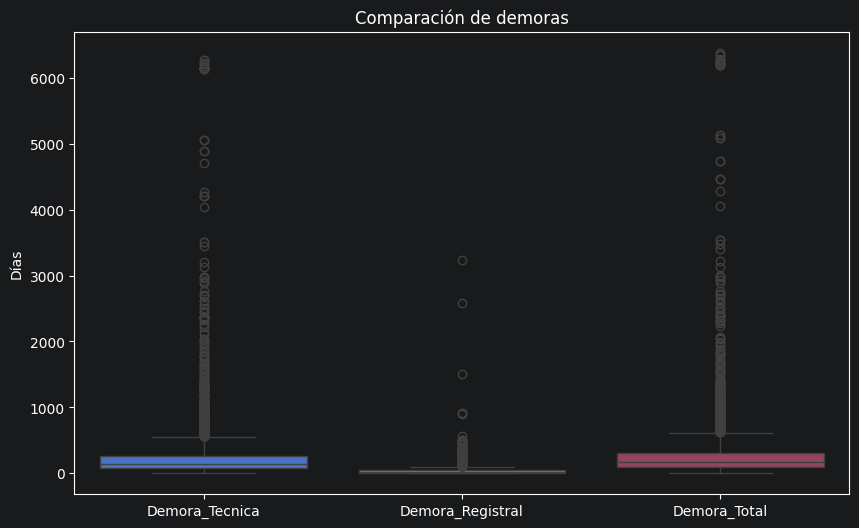

In [101]:
# Compartar las distribuciones de demoras mediante gráfico
plt.figure(figsize=(10,6))

sns.boxplot(data=df_tiempos_validos[['Demora_Tecnica', 'Demora_Registral', 'Demora_Total']])

plt.title('Comparación de demoras')
plt.ylabel('Días')

plt.show()

**Interpretación**

La comparación de las distribuciones muestra que la demora técnica concentra la mayor parte del tiempo total de tramitación. La demora registral presenta valores considerablemente menores y una menor dispersión, mientras que la demora total reproduce en gran medida el comportamiento observado en la etapa técnica.

Asimismo, se observan numerosos valores atípicos en las demoras técnica y total, lo que indica la existencia de expedientes con tiempos de tramitación excepcionalmente altos. En contraste, la demora registral presenta una distribución más homogénea y con menor cantidad de casos extremos.

Estos resultados sugieren que el principal cuello de botella del proceso se encuentra en la etapa de evaluación técnica de las solicitudes.

In [47]:
# Investigar qué porcentaje de la demora total corresponde a la etapa técnica
(df_tiempos_validos['Demora_Tecnica'].median() / df_tiempos_validos['Demora_Total'].median()) * 100

np.float64(78.57142857142857)

Adicionalmente, se observó que la demora técnica representa aproximadamente el 79% del tiempo total mediano de tramitación, lo que confirma que la etapa de evaluación técnica constituye el principal componente temporal del proceso.

### Distribución de la demora técnica

Una vez identificada la etapa técnica como el principal componente temporal del trámite, se analiza la distribución de sus tiempos de resolución. Este análisis permite conocer el comportamiento general de las demoras y detectar la presencia de casos excepcionales.

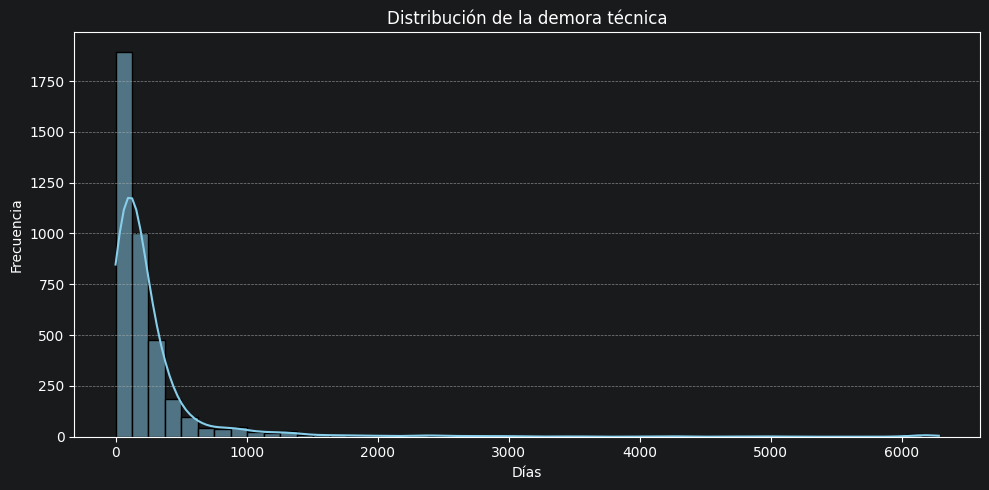

In [67]:
# Configuración del tamaño del gráfico
plt.figure(figsize=(10,5))

# Crear histograma con la curva de densidad (KDE) usando Seaborn
sns.histplot(data=df_tiempos_validos, x='Demora_Tecnica', kde=True, color='skyblue', bins=50)

# Agregar títulos y etiquetas

plt.title('Distribución de la demora técnica')
plt.xlabel('Días')
plt.ylabel('Frecuencia')

# Agregar la cuadrícula de fondo
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

**Interpretación**

La distribución de la demora técnica presenta una marcada asimetría positiva, con una concentración de trámites en los tiempos de resolución más bajos y una cola extensa hacia valores elevados.

Esto indica que la mayoría de las solicitudes son resueltas en plazos relativamente reducidos, mientras que un número menor de expedientes presenta demoras significativamente superiores al comportamiento habitual. La presencia de estos casos extremos explica la diferencia observada entre la media y la mediana de la demora técnica.

In [49]:
# Visualizar tipos de usos del agua subterránea
df_tiempos_validos['Uso'].value_counts().head(20)

Uso
Riego                       1252
Otros usos agropecuarios     891
Industrial                   800
Otros usos                   603
Consumo humano               393
Usos no consuntivos           13
Name: count, dtype: int64

## 5.3 Análisis bivariante

### Demora técnica según uso del agua

Una vez identificada la demora técnica como la principal componente temporal del trámite, se analiza su comportamiento según el uso declarado del agua subterránea.

Este análisis permite evaluar si determinados tipos de aprovechamiento presentan tiempos de evaluación superiores al resto.

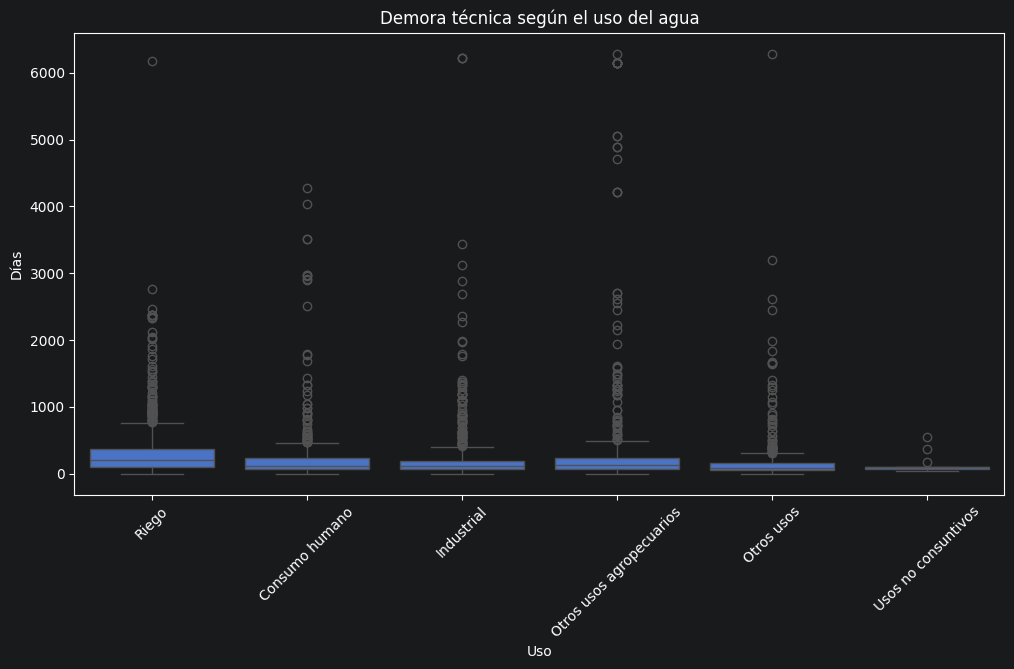

In [100]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df_tiempos_validos, x='Uso', y='Demora_Tecnica')

plt.title('Demora técnica según el uso del agua')
plt.xlabel('Uso')
plt.ylabel('Días')

plt.xticks(rotation=45)

plt.show()

In [51]:
df_tiempos_validos.groupby('Uso')['Demora_Tecnica'].median().sort_values(ascending=False)

Uso
Riego                       210.0
Otros usos agropecuarios    133.0
Consumo humano              118.0
Industrial                  112.0
Usos no consuntivos          94.0
Otros usos                   92.0
Name: Demora_Tecnica, dtype: float64

**Interpretación**

Se observan diferencias en los tiempos de evaluación técnica según el uso declarado del agua.

Las solicitudes destinadas a **Riego** presentan la mayor demora técnica mediana (210 días), superando ampliamente al resto de las categorías analizadas. Por el contrario, los trámites asociados a **Otros usos** y **Usos no consuntivos** registran los menores tiempos medianos de resolución.

Estos resultados sugieren que el uso previsto del recurso podría influir en la complejidad técnica de la evaluación, requiriendo mayores tiempos de análisis en determinadas categorías, particularmente en los proyectos vinculados al riego.

In [52]:
df_tiempos_validos['Tipo de Solicitud'].value_counts()

Tipo de Solicitud
Proyecto de Aprovechamiento    3881
Permiso de Estudio               71
Name: count, dtype: int64

In [53]:
df_tiempos_validos['Tecnicos'].nunique()

341

In [54]:
df_tiempos_validos['Departamento'].nunique()

19

### Selección de variables para el análisis bivariante

Se exploraron algunas variables categóricas con el objetivo de identificar posibles factores asociados a las diferencias observadas en la demora técnica.

En primer lugar, se analizó la variable **Tipo de Solicitud**, observándose que la gran mayoría de los registros corresponden a *Proyecto de Aprovechamiento*, mientras que los *Permisos de Estudio* representan una proporción muy reducida del conjunto de datos. Debido a este fuerte desbalance, se decidió no profundizar el análisis de esta variable.

Asimismo, se evaluó la cantidad de categorías presentes en las variables **Técnicos** y **Departamento**, con el fin de seleccionar aquellas que resultaran más adecuadas para la comparación de tiempos de tramitación.

### Demora técnica según departamento

Se analiza la distribución de la demora técnica por departamento con el objetivo de identificar posibles diferencias territoriales en los tiempos de tramitación.

Este análisis permite detectar si determinadas zonas presentan demoras sistemáticamente mayores o menores que el promedio general.

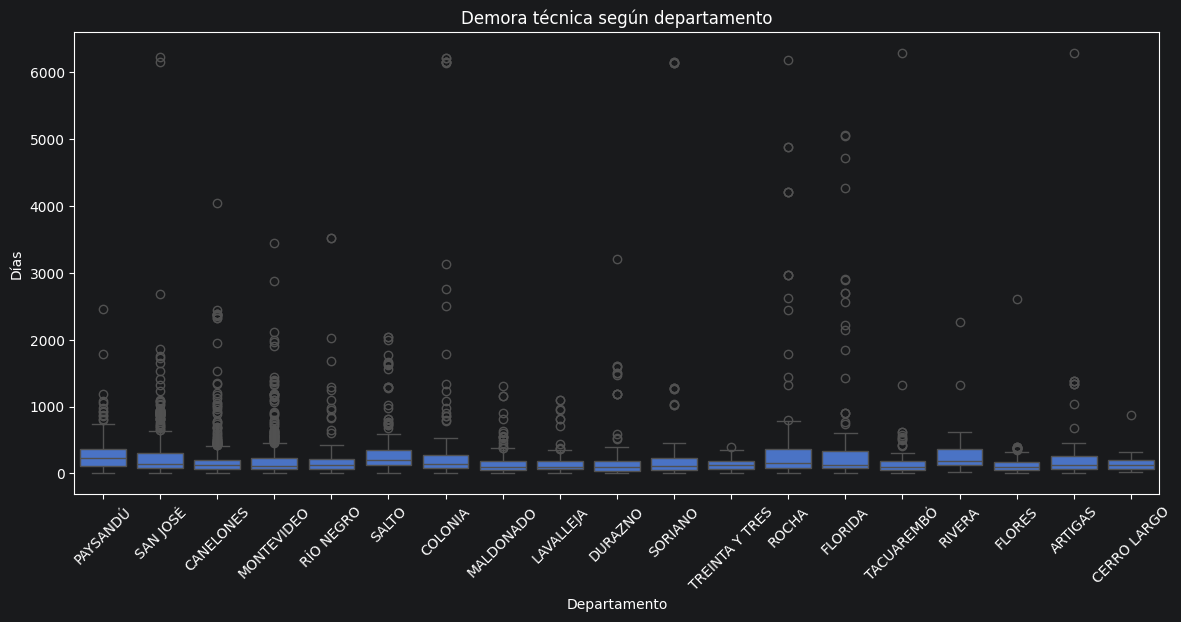

In [55]:
plt.figure(figsize=(14,6))

sns.boxplot(data=df_tiempos_validos, x='Departamento', y='Demora_Tecnica')

plt.title('Demora técnica según departamento')
plt.xlabel('Departamento')
plt.ylabel('Días')

plt.xticks(rotation=45)

plt.show()

In [56]:
df_tiempos_validos.groupby('Departamento')['Demora_Tecnica'].median().sort_values(ascending=False)

Departamento
PAYSANDÚ          224.0
SALTO             203.0
RIVERA            189.0
ROCHA             151.0
SAN JOSÉ          139.0
COLONIA           139.0
ARTIGAS           133.0
CERRO LARGO       131.0
RÍO NEGRO         128.0
TREINTA Y TRES    120.0
FLORIDA           119.5
CANELONES         119.0
MONTEVIDEO        118.0
SORIANO           114.0
TACUAREMBÓ        102.5
FLORES            101.0
LAVALLEJA         100.0
MALDONADO          97.5
DURAZNO            93.0
Name: Demora_Tecnica, dtype: float64

**Interpretación**

Se observan diferencias en los tiempos medianos de evaluación técnica entre departamentos. Los mayores tiempos se registran en Paysandú, Salto y Rivera, mientras que Durazno, Maldonado y Lavalleja presentan las menores demoras medianas.

Sin embargo, dado que la gestión de los trámites se organiza a través de oficinas regionales que agrupan varios departamentos, estas diferencias territoriales podrían estar asociadas a características organizativas o de carga de trabajo propias de cada regional. Por este motivo, resulta pertinente complementar el análisis evaluando si existen diferencias asociadas a la organización territorial del trabajo, la carga administrativa o la disponibilidad de recursos en cada oficina.


In [57]:
df_tiempos_validos['Regional'].value_counts()

Regional
MONTEVIDEO        1038
SAN JOSÉ           763
FRAY BENTOS        705
SALTO              447
SAN JOSÉ ESTE      299
DURAZNO            205
ROCHA              199
TACUAREMBÓ         139
TREINTA Y TRES      72
ARTIGAS             53
RÍO BRANCO          32
Name: count, dtype: int64

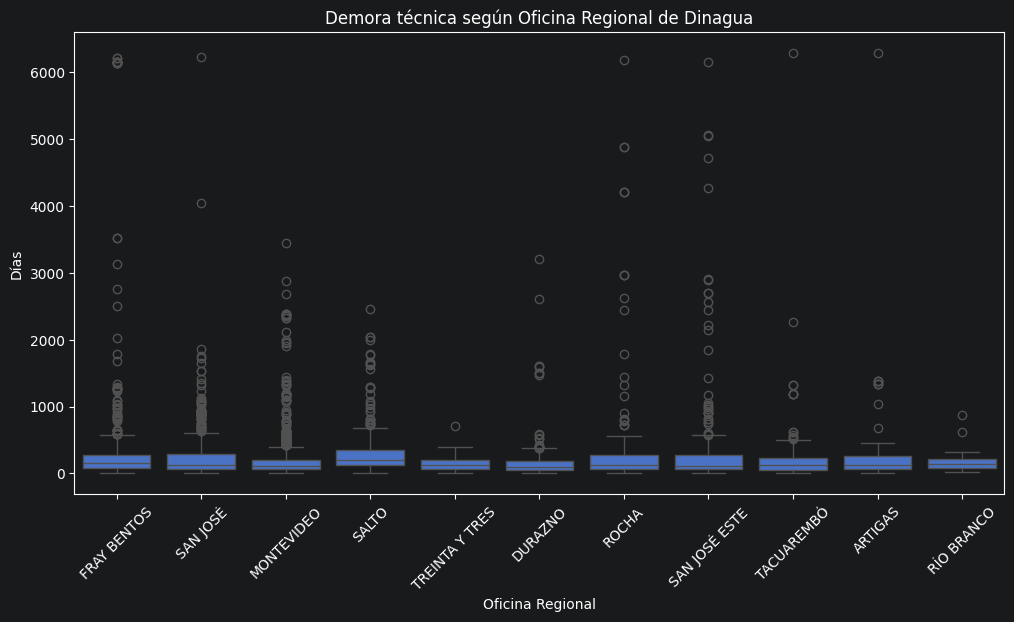

In [58]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df_tiempos_validos, x='Regional', y='Demora_Tecnica')

plt.title('Demora técnica según Oficina Regional de Dinagua')
plt.xlabel('Oficina Regional')
plt.ylabel('Días')

plt.xticks(rotation=45)

plt.show()

In [59]:
df_tiempos_validos.groupby('Regional')['Demora_Tecnica'].median().sort_values(ascending=False)

Regional
SALTO             206.0
FRAY BENTOS       151.0
RÍO BRANCO        143.0
SAN JOSÉ          133.0
ARTIGAS           133.0
ROCHA             126.0
TREINTA Y TRES    125.0
TACUAREMBÓ        121.0
MONTEVIDEO        114.0
SAN JOSÉ ESTE     106.0
DURAZNO            96.0
Name: Demora_Tecnica, dtype: float64

**Interpretación**

Se observan diferencias significativas en los tiempos medianos de evaluación técnica entre las distintas regionales.

La regional de Salto presenta la mayor demora técnica mediana (206 días), seguida por Fray Bentos y Río Branco. En el extremo opuesto, Durazno registra la menor demora mediana (96 días).

Estas diferencias sugieren que factores organizativos, operativos o vinculados a la carga de trabajo de cada regional podrían influir en los tiempos de tramitación. Por tanto, la regional responsable surge como una variable relevante para explicar parte de la variabilidad observada en las demoras técnicas.

In [60]:
df_tiempos_validos['Tecnicos'].value_counts().head(20)

Tecnicos
Rodríguez, Jorge                       344
NELSON ROBERTO MOLINA MOLINA           256
SEBASTIAN PEREZ BLANCO                 194
SERGIO ANDRES GAGLIARDI URTASUN        191
ROBERTO ANDRÉS CARRIÓN OLIVERI         173
ALEJANDRO LEONEL SCHIPILOV ZACCHINO    142
ALBERTO JOSÉ MANGANELLI TREITAS        111
Heinzen, Walter                        106
Gagliardi, Sergio                      104
Braña Pippolo, Gustavo M.               99
Schipilov, Alejandro                    94
Abelenda, Daniel                        74
ANDRÉS PÉREZ MATTIAUDA                  72
MARIA PAULA COLLAZO CARABALLO           69
Pessi Albisu, Malena                    67
Carrión, Roberto                        66
-, -                                    54
de los Santos, Jorge                    53
Carballo Tarigo, Ernesto Faustino       45
ANDRÉS,PÉREZ                            45
Name: count, dtype: int64

Durante la exploración de la variable Técnicos se identificaron diferencias en los criterios de registro de nombres, observándose múltiples formas de referirse a una misma persona. Debido a esta inconsistencia en la carga de datos, no se profundizó el análisis de esta variable en la presente etapa.

## 5.4 Análisis multivariante

Con el objetivo de evaluar posibles relaciones entre la demora técnica y las variables numéricas disponibles, se analizó la matriz de correlación de Pearson entre los indicadores temporales y las principales características técnicas de las solicitudes.

In [61]:
variables_numericas = ['Demora_Tecnica', 'Caudal', 'Volumen', 'Horas x Año', 'profundidad', 'Diámetro', 'Caudal Ensayado', 'Nivel Estático', 'Nivel Dinámico']

df_tiempos_validos[variables_numericas].corr(numeric_only=True)

,Demora_Tecnica,Caudal,Volumen,Horas x Año,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico
Demora_Tecnica,1.000000,0.004682,0.030398,0.053787,-0.029161,-0.068638,-0.006586,-0.014165,-0.007014
Caudal,0.004682,1.000000,0.063778,0.002381,0.010838,-0.003269,0.001318,-0.002344,-0.013455
Volumen,0.030398,0.063778,1.000000,0.320000,0.542545,0.009762,0.046556,0.045482,-0.019617
Horas x Año,0.053787,0.002381,0.320000,1.000000,0.095196,0.019319,0.003827,-0.028018,-0.042264
profundidad,-0.029161,0.010838,0.542545,0.095196,1.000000,-0.029352,0.026729,0.093346,0.175047
Diámetro,-0.068638,-0.003269,0.009762,0.019319,-0.029352,1.000000,0.010647,-0.022573,-0.086253
Caudal Ensayado,-0.006586,0.001318,0.046556,0.003827,0.026729,0.010647,1.000000,0.062710,0.048522
Nivel Estático,-0.014165,-0.002344,0.045482,-0.028018,0.093346,-0.022573,0.062710,1.000000,0.797893
Nivel Dinámico,-0.007014,-0.013455,-0.019617,-0.042264,0.175047,-0.086253,0.048522,0.797893,1.000000


**Interpretación**

Los resultados muestran que la demora técnica presenta correlaciones muy bajas con las variables numéricas analizadas, incluyendo caudal, volumen, profundidad, diámetro y niveles del acuífero.

Esto sugiere que las diferencias observadas en los tiempos de tramitación no estarían asociadas principalmente a las características físicas de los proyectos, sino a factores de naturaleza administrativa u organizativa.

En los análisis bivariantes realizados previamente, las variables que mostraron una mayor capacidad para explicar las diferencias en los tiempos de evaluación fueron el uso declarado del agua y la regional responsable de la gestión del trámite.

## 5.5 Principales hallazgos

A partir del análisis realizado se identificaron los siguientes resultados principales:

- La etapa técnica constituye el principal componente temporal del trámite, representando aproximadamente el 79% del tiempo total mediano de tramitación.
- La demora registral presenta tiempos considerablemente menores y una menor dispersión.
- Existen expedientes con demoras excepcionalmente altas, lo que genera una distribución fuertemente asimétrica de los tiempos de resolución.
- El uso declarado del agua influye en los tiempos de evaluación, siendo los proyectos destinados a riego los que presentan mayores demoras medianas.
- Se observaron diferencias significativas entre regionales, lo que sugiere la existencia de factores organizativos asociados a los tiempos de tramitación.
- Las variables técnicas e hidráulicas analizadas no muestran una relación relevante con la demora técnica.

En conjunto, los resultados indican que los tiempos de tramitación parecen estar más asociados a factores administrativos y de gestión que a la complejidad técnica de las características físicas de los proyectos evaluados.

### Resultados de la depuración

Luego de la validación y depuración de los datos, se obtuvo un conjunto de registros consistente para el análisis temporal. Se excluyeron los trámites sin finalizar, los registros con secuencias temporales inválidas y se corrigieron errores evidentes de carga de fechas.

A partir de este conjunto depurado se realizó el análisis de las demoras técnicas, registrales y totales asociadas a los trámites.

### Estadísticas descriptivas de los indicadores temporales

Antes de realizar los análisis gráficos, se examinan algunas medidas descriptivas de los indicadores de demora construidos. Esto permite conocer los tiempos promedio de tramitación, la dispersión de los datos y la existencia de posibles valores extremos.

# Paso 6: ingeniería de características

La **ingeniería de características** es el proceso de transformar los datos crudos o combinar variables existentes para crear nuevos indicadores que faciliten el aprendizaje del modelo predictivo.

### Ajuste de enfoque institucional y delimitación del problema:

Tras el análisis exploratorio, se determina que modelar variables estrictamente hidráulicas (como caudal o profundidad) presenta una limitación teórica crítica debido a la ausencia de datos geológicos específicos de los acuíferos en este conjunto de datos.

Por lo tanto, redefinimos el problema predictivo hacia la **gestión y eficiencia administrativa hídrica**. El objetivo del modelo será predecir **el tiempo de resolución de los trámites de solicitud de perforaciones**. Esto nos permitirá evaluar el impacto de variables logísticas y regulatorias, como por ejemplo, si las solicitudes destinadas a **Riego** (que conllevan una articulación e inspección adicional con ministerios externos) presentan un comportamiento predictivo diferenciado frente a otros usos.


## 6.1. Selección de registros para modelado

A partir de los resultados obtenidos en el análisis exploratorio, se seleccionan los registros aptos para el entrenamiento del modelo predictivo.

Dado que el objetivo será estimar la demora técnica de los trámites, resulta necesario trabajar únicamente con expedientes finalizados que cuenten con fechas válidas de solicitud y resolución.

Para ello se aplican los siguientes criterios:

Excluir solicitudes que permanecen en estudio o pendientes de resolución.
Conservar únicamente registros con secuencias temporales válidas.
Mantener observaciones que permitan calcular correctamente la variable objetivo Demora_Tecnica.

De esta forma se obtiene un conjunto histórico consistente para el desarrollo del modelo predictivo.

In [68]:
# Revistar la distribución de datos según el estado del trámite ante Dinagua
df['Estado'].value_counts(dropna=False)

Estado
Registrada                 4700
En Estudio                  360
Pendiente de Resolución      99
Name: count, dtype: int64

In [69]:
# Crear un dataset histórico solo con aquellos trámites finalizados, es decir, en estado "Registrada"
df_hist = df[df['Estado'] == 'Registrada'].copy()

print(df_hist.shape[0])

4700


In [70]:
# Analizar si las solicitudes en estado Registrada tienen fechas de solicitud o resolución faltantes
df_hist[['Fecha de Solicitud', 'Fecha de Resolución']].isna().sum()

Fecha de Solicitud     1
Fecha de Resolución    1
dtype: int64

## 6.2. Construcción de características para el modelo

Una vez definido el problema predictivo, se seleccionarán y construirán las variables que serán utilizadas durante el entrenamiento del modelo.

Las principales características consideradas son:

Demora_Tecnica (Variable Objetivo / Target): representa la cantidad de días transcurridos entre la fecha de solicitud y la fecha de resolución del trámite. Esta variable constituye el principal indicador de desempeño del proceso administrativo y será la variable a predecir.
Es_Riego (Variable Predictora): variable binaria derivada de la columna Uso, que toma valor 1 para solicitudes destinadas a riego y 0 para el resto de los usos. Su incorporación se fundamenta en los resultados del análisis exploratorio, donde los trámites asociados al riego presentaron tiempos medianos de resolución superiores al resto de las categorías analizadas.

La construcción de estas variables permite transformar información operativa en características aptas para el modelado predictivo.

In [71]:
# Crear variable binaria para identificar solicitudes de riego

df_tiempos_validos['Es_Riego'] = (df_tiempos_validos['Uso'].apply(lambda x: 1 if str(x).upper() == 'RIEGO' else 0))

# Verificar el resultado

df_tiempos_validos[['Uso', 'Es_Riego', 'Demora_Tecnica']].head()

,Uso,Es_Riego,Demora_Tecnica
1,Riego,1,223
2,Riego,1,224
3,Riego,1,191
4,Riego,1,179
5,Riego,1,133


In [72]:
# Dataset base para modelado

df_modelo = df_tiempos_validos.copy()

print(f"Registros disponibles para modelado: {df_modelo.shape[0]}")

Registros disponibles para modelado: 3952


Una vez realizada la depuración temporal y la validación de registros durante el análisis exploratorio, se adopta el conjunto df_tiempos_validos como base para el modelado.

Este dataset contiene únicamente expedientes con secuencias temporales válidas y permite calcular correctamente la variable objetivo Demora_Tecnica.

## 6.3. Análisis de outliers en tiempos de gestión

Habiendo consolidado el dataset de entrenamiento con 4,014 registros correspondientes a trámites finalizados, es necesario evaluar la distribución de la variable objetivo `Dias_Demora`.

En la dinámica de la administración pública, existen expedientes atípicos que sufren demoras extraordinarias por conflictos legales o catastrales ajenos al flujo normal. Identificar y tratar estos valores extremos (outliers) es un paso crítico para evitar que el modelo de asuma tiempos de resolución distorsionados.

In [73]:
# Analizamos los percentiles clave de los días de demora para identificar el comportamiento extremo
df_modelo['Demora_Tecnica'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])

count    3952.000000
mean      271.481528
std       566.518888
min         0.000000
25%        71.000000
50%       132.000000
75%       265.250000
90%       502.900000
95%       908.000000
99%      2704.000000
max      6284.000000
Name: Demora_Tecnica, dtype: float64

> ### Observaciones del análisis de outliers en la demora técnica:
>
> * **Comportamiento central estable:** el 50% de los trámites presentan una demora técnica menor o igual a 132 días (mediana), mientras que el 75% se resuelve técnicamente en menos de 266 días.
>
> * **Distribución asimétrica:** el promedio de 271 días es superior a la mediana debido a la presencia de expedientes con demoras excepcionalmente altas.
>
> * **Valores extremos:** se observan casos que alcanzan los 6.284 días de demora técnica, evidenciando la existencia de expedientes atípicos que se apartan significativamente del comportamiento general.
>
> * **Criterio de depuración para modelado:** con el fin de reducir la influencia de estos valores extremos sobre el algoritmo predictivo, se adopta como límite operativo el percentil 95 de la distribución (908 días).

In [74]:
# Eliminar valores extremos utilizando el percentil 95 de la demora técnica

limite_p95 = 908

df_modelo_limpio = df_modelo[df_modelo['Demora_Tecnica'] <= limite_p95].copy()

print(f"Filas resultantes para entrenar el modelo: {df_modelo_limpio.shape[0]}")
print(f"Nueva demora máxima: {df_modelo_limpio['Demora_Tecnica'].max()} días")
print(f"Nueva demora promedio: {df_modelo_limpio['Demora_Tecnica'].mean():.1f} días")

Filas resultantes para entrenar el modelo: 3757
Nueva demora máxima: 908 días
Nueva demora promedio: 175.3 días


> ### Resultado de la depuración de outliers
>
> Aplicando como límite superior el percentil 95 de la distribución de la demora técnica (908 días), se obtuvo un conjunto de datos de 3.757 registros para el entrenamiento del modelo.
>
> Esta depuración permite reducir la influencia de expedientes excepcionalmente demorados, manteniendo al mismo tiempo la gran mayoría de las observaciones históricas.
>
> El nuevo conjunto presenta una demora técnica promedio de 175 días y un máximo de 908 días, representando de forma más adecuada el comportamiento habitual de los trámites.

### Visualización de características inferidas: impacto de la Regulación de Riego

Para validar de forma preliminar el peso predictivo de la nueva variable estructurada (`Es_Riego`), se realizará un análisis de densidad (KDE Plot) sobre la variable objetivo (`Dias_Demora`).

El objetivo técnico es contrastar las distribuciones temporales de los trámites: si la hipótesis institucional es correcta, la curva correspondiente a los proyectos de **Riego Agrícola** debería exhibir un desplazamiento hacia la derecha (mayor latencia), reflejando estadísticamente el impacto del circuito de aprobación interministerial frente al resto de los usos estándar.

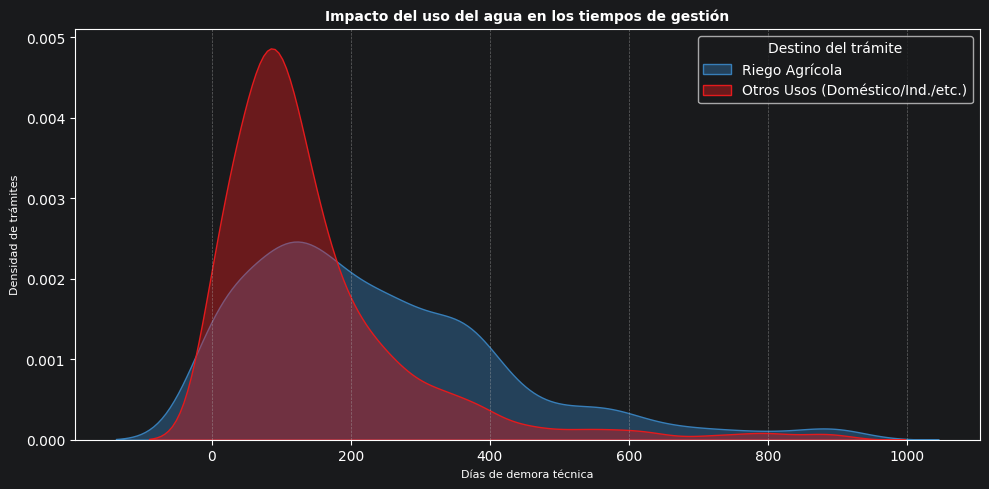

In [75]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 5))

# Crear las curvas de densidad para Riego (1) y Otros Usos (0)
# Usar el dataframe filtrado sin los outliers
sns.kdeplot(data=df_modelo_limpio, x='Demora_Tecnica', hue='Es_Riego', fill=True, common_norm=False, palette='Set1', alpha=0.4)

# Ajustar títulos
plt.title('Impacto del uso del agua en los tiempos de gestión', fontsize=10, fontweight='bold')
plt.xlabel('Días de demora técnica', fontsize=8)
plt.ylabel('Densidad de trámites', fontsize=8)

# Modificar las etiquetas de la leyenda
plt.legend(title='Destino del trámite', labels=['Riego Agrícola', 'Otros Usos (Doméstico/Ind./etc.)'])

# Visualización gráfica
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

> ### Conclusiones de la visualización
>
> La distribución de la demora técnica para los trámites asociados a riego presenta un desplazamiento hacia valores más altos en comparación con el resto de los usos.
>
> Este comportamiento coincide con los resultados obtenidos durante el análisis exploratorio, donde las solicitudes destinadas a riego registraron las mayores demoras medianas entre las categorías analizadas.
>
> En consecuencia, la variable `Es_Riego` constituye una característica relevante para el modelo predictivo, ya que captura parte de la variabilidad observada en los tiempos de evaluación técnica.

## 6.4. Conclusión de la preparación de datos

Como resultado del proceso de ingeniería de características, se obtuvo un conjunto de datos depurado y preparado para el modelado predictivo.

La variable objetivo seleccionada es la demora técnica de los trámites, mientras que las variables predictoras incluyen atributos administrativos, territoriales y técnicos disponibles al momento de la solicitud.

Asimismo, se construyeron nuevas características derivadas y se controló la influencia de valores extremos mediante un criterio de depuración basado en percentiles, obteniéndose un conjunto de entrenamiento representativo del comportamiento habitual de los trámites analizados.

# Paso 7: Split (dos métodos o enfoques)

El objetivo del split es dividir nuestro conjunto de datos procesados en dos: un grupo de **Entrenamiento (Train)** para que el modelo aprenda los patrones, y un grupo de **Prueba (Test)** para evaluar su capacidad real de predicción con datos que nunca vio.

## 7.1. Primer enfoque: codificación y escalado antes del Split

En este primer enfoque, se realizarán los procesos de transformación global de las variables (como convertir los departamentos o tipos de solicitudes de texto a números mediante codificación, o escalar magnitudes si fuera necesario) en **todo el dataset completo**, y posteriormente se aplicará la división entre Train y Test.

* **Ventaja:** garantiza de forma sencilla que tanto los datos de entrenamiento como los de prueba queden exactamente con la misma estructura, dimensiones y categorías codificadas de manera homogénea.
* **Riesgo teórico (Data Leakage):** al procesar todo el conjunto junto, parte de la información estadística del grupo de prueba podría "filtrarse" indirectamente en los parámetros de escalado, aunque para variables estrictamente categóricas este enfoque sería muy común y práctico.

In [76]:
# Guardar en el directorio '../data/processed' un archivo .csv con los datos del dataframe df

from pathlib import Path

# Definir la ruta hacia la carpeta 'data/processed' usando Path
processed_dir = Path("../data/processed")

# Crear la carpeta si no existe (parents=True permite crear carpetas intermedias)
processed_dir.mkdir(parents=True, exist_ok=True)

# Guardar el DataFrame con los cambios consolidados en un archivo CSV único
df_modelo_limpio.to_csv(processed_dir / "water_processed.csv", index=False)

print("--- ¡Dataset Base Guardado con éxito! ---")
print(f"El archivo unificado se guardó en: {processed_dir / 'tramites_procesados.csv'}")

--- ¡Dataset Base Guardado con éxito! ---
El archivo unificado se guardó en: ..\data\processed\tramites_procesados.csv


In [77]:
from sklearn.model_selection import train_test_split
import pandas as pd

In [78]:
# Seleccionar las variables predictoras (X) que tienen sentido institucional
# Se usará 'Es_Riego', 'Regional' y 'Departamento'
variables_predictores = ['Es_Riego', 'Regional', 'Departamento']

# Aplicar One-Hot Encoding a las variables de texto (como Departamento)
# Esto transforma 'MONTEVIDEO', 'CANELONES', etc., en columnas de 0 y 1 que el modelo entiende
X = pd.get_dummies(df_modelo_limpio[variables_predictores], drop_first=True)

# Definir el Target (y)
y = df_modelo_limpio['Demora_Tecnica']

# Realizar el Split (Enfoque 1: separar después de codificar todo el dataset)
# Reservar el 20% de los datos para el examen final (test_size=0.20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Verificar las dimensiones resultantes
print(f"Dataset total de modelado: {X.shape[0]} registros")
print(f"--- Enfoque 1 Concluido ---")
print(f"Registros destinados a Entrenamiento (X_train): {X_train.shape[0]}")
print(f"Registros destinados a Prueba/Examen (X_test): {X_test.shape[0]}")
print(f"Cantidad de variables numéricas finales (incluyendo dummies): {X_train.shape[1]}")

Dataset total de modelado: 3757 registros
--- Enfoque 1 Concluido ---
Registros destinados a Entrenamiento (X_train): 3005
Registros destinados a Prueba/Examen (X_test): 752
Cantidad de variables numéricas finales (incluyendo dummies): 29


## 7.2. Segundo enfoque: codificación y escalado después del Split

En este segundo enfoque, el dataset crudo y limpio se divide **primero** en los conjuntos de entrenamiento (Train) y prueba (Test). Las transformaciones (como la codificación de variables categóricas o escalados numéricos si los hubiera) se calculan e implementan de forma estrictamente separada.

* **Ventaja (rigurosidad metodológica):** refleja fielmente el escenario del mundo real. El conjunto de entrenamiento se procesa de forma totalmente aislada, evitando que parámetros estadísticos del conjunto de prueba contaminen el aprendizaje del modelo (previene el *Data Leakage*).
* **Desventaja:** requiere un diseño de código ligeramente más estructurado para asegurar que los mismos criterios aplicados en el conjunto Train se repliquen en el conjunto Test (por ejemplo, manejando categorías nuevas o inesperadas que puedan aparecer en el set de validación).

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

In [80]:
# Definir las variables predictoras puras (X_puro) y el target (y_puro)
X_puro = df_modelo_limpio[['Es_Riego', 'Regional', 'Departamento']]
y_puro = df_modelo_limpio['Demora_Tecnica']

# Realizar el split antes de codificar cualquier dato texto
X_train_puro, X_test_puro, y_train, y_test = train_test_split(X_puro, y_puro, test_size=0.20, random_state=42)

In [81]:
# Inicializar el codificador oficial de Scikit-Learn
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# handle_unknown='ignore' evita errores si aparece alguna categoría nueva en el conjunto de prueba

# Definir las variables categóricas que deben transformarse a formato numérico
# Los modelos no pueden trabajar directamente con texto
columnas_categoricas = ['Regional', 'Departamento']

# AJUSTE Y TRANSFORMACIÓN DEL CONJUNTO DE ENTRENAMIENTO
# El codificador aprende todas las categorías presentes en Train y las transforma en columnas binarias (One-Hot Encoding)
encoded_train = encoder.fit_transform(X_train_puro[columnas_categoricas])

# TRANSFORMACIÓN DEL CONJUNTO DE PRUEBA
# Se aplica exactamente el mismo esquema aprendido en Train
# sin volver a recalcular categorías
encoded_test = encoder.transform(X_test_puro[columnas_categoricas])

# Recuperar los nombres de las nuevas columnas creadas por el One-Hot Encoding
columnas_codificadas = encoder.get_feature_names_out(columnas_categoricas)

# Convertir la matriz numérica de entrenamiento en DataFrame
# para conservar nombres de columnas e índices originales
X_train_cat = pd.DataFrame(encoded_train, columns=columnas_codificadas, index=X_train_puro.index)

# Convertir la matriz numérica de prueba en DataFrame
X_test_cat = pd.DataFrame(encoded_test, columns=columnas_codificadas, index=X_test_puro.index)

# Construir el dataset final de entrenamiento uniendo la variable binaria Es_Riego con las columnas codificadas
X_train_final = pd.concat([X_train_puro[['Es_Riego']], X_train_cat], axis=1)

# Construir el dataset final de prueba utilizando exactamente la misma estructura
X_test_final = pd.concat([X_test_puro[['Es_Riego']], X_test_cat], axis=1)

In [82]:
# Verificar que las dimensiones mantengan la coherencia absoluta
print(f"--- Enfoque 2 Concluido (Riguroso) ---")
print(f"Dimensiones de X_train_final: {X_train_final.shape}")
print(f"Dimensiones de X_test_final: {X_test_final.shape}")
print(f"¿Los conjuntos de Train y Test tienen exactamente las mismas columnas?: {list(X_train_final.columns) == list(X_test_final.columns)}")

--- Enfoque 2 Concluido (Riguroso) ---
Dimensiones de X_train_final: (3005, 31)
Dimensiones de X_test_final: (752, 31)
¿Los conjuntos de Train y Test tienen exactamente las mismas columnas?: True


In [83]:
print(f"Cantidad de variables predictoras finales: {X_train_final.shape[1]}")

Cantidad de variables predictoras finales: 31


In [84]:
import os

# Veritifcar la existencia de la carpeta 'data/processed'
processed_dir = '../data/processed'
os.makedirs(processed_dir, exist_ok=True)

# Guardar las matrices de características (X) con sus columnas y renglones ordenados
X_train_final.to_csv(f"{processed_dir}/X_train_final.csv", index=True)
X_test_final.to_csv(f"{processed_dir}/X_test_final.csv", index=True)

# Guardar los vectores de la variable objetivo (y) convirtiéndolos a DataFrame para mantener el formato limpio
pd.DataFrame(y_train).to_csv(f"{processed_dir}/y_train.csv", index=True)
pd.DataFrame(y_test).to_csv(f"{processed_dir}/y_test.csv", index=True)

print("--- ¡Conjuntos de datos guardados con éxito! ---")
print(f"Los 4 archivos CSV se exportaron correctamente a: {processed_dir}")

--- ¡Conjuntos de datos guardados con éxito! ---
Los 4 archivos CSV se exportaron correctamente a: ../data/processed


### 7.3. Verificación visual de la distribución del Split

Para garantizar que el proceso de partición bajo el **segundo enfoque** se realizó de manera equitativa y mantiene las proporciones deseadas (80% entrenamiento / 20% prueba), se realizará una representación gráfica del volumen de datos asignado a cada conjunto independiente.

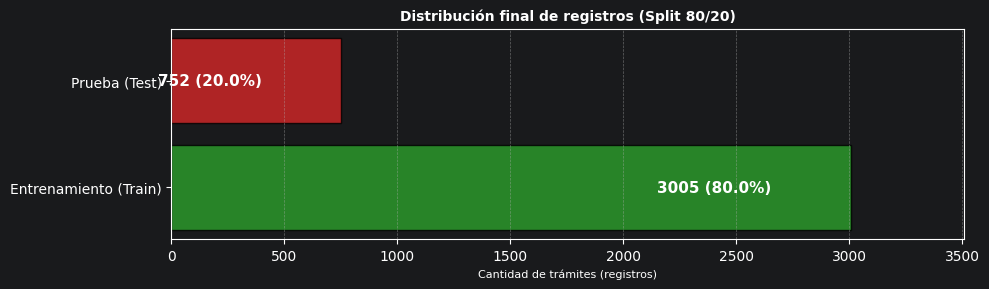

In [85]:
import matplotlib.pyplot as plt

# Preparar los datos del tamaño de los conjuntos
componentes = ['Entrenamiento (Train)', 'Prueba (Test)']
tamaños = [X_train_final.shape[0], X_test_final.shape[0]]
colores = ['#2ca02c', '#d62728'] # Verde para estudiar, Rojo para el examen

# Configurar el gráfico
plt.figure(figsize=(10, 3))

# Crear un gráfico de barras horizontales
barras = plt.barh(componentes, tamaños, color=colores, alpha=0.8, edgecolor='black')

# Agregar las etiquetas con el número exacto y el porcentaje adentro de cada barra
total_datos = sum(tamaños)
for barra in barras:
    ancho = barra.get_width()
    porcentaje = (ancho / total_datos) * 100
    plt.text(ancho - 350, barra.get_y() + barra.get_height()/2,
             f'{int(ancho)} ({porcentaje:.1f}%)',
             va='center', ha='right', color='white', fontweight='bold', fontsize=11)

# Formato institucional
plt.title('Distribución final de registros (Split 80/20)', fontsize=10, fontweight='bold')
plt.xlabel('Cantidad de trámites (registros)', fontsize=8)
plt.xlim(0, max(tamaños) + 500)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 6. Mostrar gráfico
plt.tight_layout()
plt.show()

### Resultado del segundo enfoque de partición

Luego de realizar la división inicial entre entrenamiento y prueba y aplicar posteriormente la codificación de las variables categóricas, se obtuvieron conjuntos consistentes para el modelado.

El conjunto de entrenamiento quedó conformado por 3.005 registros, mientras que el conjunto de prueba contiene 752 registros. Tras la codificación de las variables territoriales (`Regional` y `Departamento`), se generaron 31 variables predictoras finales.

La verificación realizada confirma que ambos conjuntos poseen exactamente la misma estructura de columnas, garantizando la correcta aplicación de los modelos de aprendizaje automático en las etapas posteriores.

In [86]:
print(X_train_final.shape[1])

31


In [87]:
print(X_train_final.columns.tolist())

['Es_Riego', 'Regional_ARTIGAS', 'Regional_DURAZNO', 'Regional_FRAY BENTOS', 'Regional_MONTEVIDEO', 'Regional_ROCHA', 'Regional_RÍO BRANCO', 'Regional_SALTO', 'Regional_SAN JOSÉ', 'Regional_SAN JOSÉ ESTE', 'Regional_TACUAREMBÓ', 'Regional_TREINTA Y TRES', 'Departamento_ARTIGAS', 'Departamento_CANELONES', 'Departamento_CERRO LARGO', 'Departamento_COLONIA', 'Departamento_DURAZNO', 'Departamento_FLORES', 'Departamento_FLORIDA', 'Departamento_LAVALLEJA', 'Departamento_MALDONADO', 'Departamento_MONTEVIDEO', 'Departamento_PAYSANDÚ', 'Departamento_RIVERA', 'Departamento_ROCHA', 'Departamento_RÍO NEGRO', 'Departamento_SALTO', 'Departamento_SAN JOSÉ', 'Departamento_SORIANO', 'Departamento_TACUAREMBÓ', 'Departamento_TREINTA Y TRES']


# Paso 8: Scaling & Encoding (Escalado de valores)

El **escalado de características (Feature Scaling)** es una fase crítica del preprocesamiento para algoritmos basados en distancias (como KNN, SVM o Regresiones lineales/logísticas con regularización). Evita que aquellas variables con magnitudes numéricas intrínsecamente mayores dominen sesgadamente el aprendizaje del modelo.

## 8.1. Normalización (StandardScaler) con enfoque riguroso

Siguiendo las buenas prácticas consolidadas en el Paso 7 (segundo enfoque), cualquier proceso de escalado debe **ajustarse (fit) exclusivamente con los datos de entrenamiento (Train)** para capturar su media y desviación estándar. Posteriormente, esos mismos parámetros se aplican (transform) tanto al conjunto de Train como al de Prueba (Test), blindando el proceso contra el *Data Leakage*.

En el conjunto de datos actual, las variables predictoras están representadas mediante variables binarias generadas a partir de la codificación One-Hot de las características territoriales y administrativas. Aunque este tipo de variables no requiere estrictamente normalización para muchos algoritmos, se incorpora el escalado como parte de un pipeline formal de aprendizaje automático, facilitando la incorporación futura de variables numéricas continuas y manteniendo la consistencia metodológica del proceso.

In [88]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Verificar dimensiones antes del escalado

print(f"X_train_final: {X_train_final.shape}")
print(f"X_test_final: {X_test_final.shape}")

# Crear el objeto del escalador (la herramienta de normalización)
scaler = StandardScaler()

# Escalar los datos de forma separada del conjunto de train
X_train_scaled_array = scaler.fit_transform(X_train_final)

# Transformar el conjunto de test
X_test_scaled_array = scaler.transform(X_test_final)

# Convertir los resultados de vuelta a tablas (DataFrames) legibles de Pandas
X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=X_train_final.columns, index=X_train_final.index)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=X_test_final.columns, index=X_test_final.index)

# Mostrar encabezado con nuevos resutados
print("--- Datos de Entrenamiento Escalados con exito (Muestra de Control) ---")
X_train_scaled.head()

X_train_final: (3005, 31)
X_test_final: (752, 31)
--- Datos de Entrenamiento Escalados con exito (Muestra de Control) ---


,Es_Riego,Regional_ARTIGAS,Regional_DURAZNO,Regional_FRAY BENTOS,Regional_MONTEVIDEO,Regional_ROCHA,Regional_RÍO BRANCO,Regional_SALTO,Regional_SAN JOSÉ,Regional_SAN JOSÉ ESTE,...,Departamento_MONTEVIDEO,Departamento_PAYSANDÚ,Departamento_RIVERA,Departamento_ROCHA,Departamento_RÍO NEGRO,Departamento_SALTO,Departamento_SAN JOSÉ,Departamento_SORIANO,Departamento_TACUAREMBÓ,Departamento_TREINTA Y TRES
1415,1.494878,-0.106976,-0.234,-0.466989,-0.606444,-0.225165,-0.087823,-0.351233,2.057958,-0.288571,...,-0.442473,-0.274807,-0.102096,-0.14869,-0.220226,-0.298601,2.487769,-0.183608,-0.136543,-0.105374
588,-0.668951,-0.106976,-0.234,-0.466989,-0.606444,-0.225165,-0.087823,2.847114,-0.485919,-0.288571,...,-0.442473,3.638916,-0.102096,-0.14869,-0.220226,-0.298601,-0.401967,-0.183608,-0.136543,-0.105374
2786,-0.668951,-0.106976,-0.234,-0.466989,1.648957,-0.225165,-0.087823,-0.351233,-0.485919,-0.288571,...,-0.442473,-0.274807,-0.102096,-0.14869,-0.220226,-0.298601,-0.401967,-0.183608,-0.136543,-0.105374
4241,-0.668951,-0.106976,-0.234,2.141378,-0.606444,-0.225165,-0.087823,-0.351233,-0.485919,-0.288571,...,-0.442473,-0.274807,-0.102096,-0.14869,-0.220226,-0.298601,-0.401967,5.446399,-0.136543,-0.105374
1445,1.494878,-0.106976,-0.234,-0.466989,1.648957,-0.225165,-0.087823,-0.351233,-0.485919,-0.288571,...,2.260027,-0.274807,-0.102096,-0.14869,-0.220226,-0.298601,-0.401967,-0.183608,-0.136543,-0.105374


### Resultado del escalado

El procedimiento de normalización fue ajustado exclusivamente utilizando los datos de entrenamiento y posteriormente aplicado a ambos conjuntos de datos.

De esta forma se preserva la independencia del conjunto de prueba y se evita la incorporación involuntaria de información futura durante el entrenamiento del modelo.

## Guardando los scalers y encoders

In [89]:
import joblib

# Crear una carpeta llamada 'models' en mi proyecto
os.makedirs('../models', exist_ok=True)

# Guardar el codificador de departamentos (OneHotEncoder) del Paso 7

joblib.dump(encoder, '../models/water-one-hot-encoder.pkl')

# Guardar el escalador (StandardScaler) qusado en el Paso 8
joblib.dump(scaler, '../models/water-standard-scaler.pkl')

print("--- ¡Herramientas de preprocesamiento guardadas ---")
print("Se han creado los archivos '.pkl' dentro de la carpeta 'models'.")

--- ¡Herramientas de preprocesamiento guardadas ---
Se han creado los archivos '.pkl' dentro de la carpeta 'models'.


# Paso 9: Selección de características

La **selección de características (Feature Selection)** consiste en identificar cuáles variables predictoras aportan mayor información para explicar el comportamiento de la variable objetivo.

Este proceso permite:

1. Simplificar el modelo y facilitar su interpretación.
2. Reducir el tiempo de entrenamiento.
3. Disminuir el riesgo de sobreajuste (*overfitting*).
4. Eliminar variables poco informativas o redundantes.
5. Identificar qué factores tienen mayor influencia sobre los tiempos de gestión administrativa.

En este proyecto se utilizará la herramienta **SelectKBest** de Scikit-Learn junto con la prueba estadística **f_regression**, adecuada para problemas de regresión donde la variable objetivo es numérica continua.

El análisis se realizará sobre las variables ya procesadas y escaladas en los pasos anteriores, manteniendo el enfoque metodológico riguroso de utilizar exclusivamente los datos de entrenamiento para ajustar los procedimientos estadísticos.

In [110]:
from sklearn.feature_selection import f_regression

In [111]:
# Se utiliza f_regression porque la variable objetivo Demora_Tecnica es una variable numérica continua

k_elegido = 5

selection_model = SelectKBest(score_func=f_regression, k=k_elegido)

# Ajustar la herramienta utilizando únicamente los datos de entrenamiento

selection_model.fit(X_train_scaled, y_train)

# Obtener una máscara booleana indicando qué variables fueron seleccionadas

ix = selection_model.get_support()

# Crear nuevos conjuntos conservando únicamente las variables más relevantes

X_train_selected = X_train_scaled.loc[:, ix]
X_test_selected = X_test_scaled.loc[:, ix]

# Mostrar resultados

print(f"--- Selección de características concluida (k={k_elegido}) ---")
print()
print("Variables seleccionadas:")
print(list(X_train_selected.columns))

--- Selección de características concluida (k=5) ---

Variables seleccionadas:
['Es_Riego', 'Regional_MONTEVIDEO', 'Regional_SALTO', 'Departamento_PAYSANDÚ', 'Departamento_SALTO']


In [112]:
# Mostrar el puntaje estadístico de cada variable

scores = selection_model.scores_

resultado_scores = pd.DataFrame({'Variable': X_train_scaled.columns, 'Score': scores})

resultado_scores = resultado_scores.sort_values(by='Score', ascending=False)

resultado_scores.head(10)

,Variable,Score
0,Es_Riego,178.869852
7,Regional_SALTO,49.852178
22,Departamento_PAYSANDÚ,40.320490
26,Departamento_SALTO,32.498814
4,Regional_MONTEVIDEO,17.752216
2,Regional_DURAZNO,12.520530
28,Departamento_SORIANO,12.318805
16,Departamento_DURAZNO,10.864451
27,Departamento_SAN JOSÉ,10.261763
8,Regional_SAN JOSÉ,9.755685


## 9.2. Interpretación de los resultados

La selección de características permitió identificar cuáles variables presentan la asociación estadística más fuerte con la demora técnica de los trámites.

Desde una perspectiva institucional, este resultado es particularmente relevante porque permite distinguir qué factores territoriales y administrativos influyen con mayor intensidad sobre los tiempos de gestión observados.

Las variables seleccionadas serán utilizadas en la etapa posterior de modelado, contribuyendo a construir algoritmos más simples, interpretables y eficientes.

## 9.2. Interpretación de los resultados

La aplicación de SelectKBest permitió identificar las cinco variables con mayor capacidad explicativa sobre la demora técnica de los trámites.

Las variables seleccionadas fueron:

- Es_Riego
- Regional_MONTEVIDEO
- Regional_SALTO
- Departamento_PAYSANDÚ
- Departamento_SALTO

El resultado confirma varias observaciones realizadas previamente durante el Análisis Exploratorio de Datos (EDA).

La variable **Es_Riego** obtuvo el puntaje más alto por amplio margen, lo que indica que el destino del agua constituye el principal factor asociado a los tiempos de resolución. Este hallazgo resulta consistente con la hipótesis institucional planteada, ya que los proyectos destinados a riego suelen requerir instancias adicionales de evaluación técnica y coordinación con otros organismos públicos.

Asimismo, las variables territoriales asociadas a las regionales y departamentos de **Salto**, **Paysandú** y **Montevideo** muestran una influencia significativa sobre la demora técnica observada. Esto sugiere la existencia de diferencias operativas o de carga de trabajo entre regiones, aspecto que también había surgido en el análisis descriptivo de los tiempos de gestión.

En conjunto, los resultados permiten concluir que tanto el tipo de uso solicitado como la ubicación territorial del trámite son factores relevantes para explicar las variaciones en los tiempos de resolución técnica.

# Conclusiones generales

A partir del análisis realizado sobre los trámites de perforaciones gestionados por DINAGUA, fue posible identificar patrones relevantes en los tiempos de resolución y registro.

La construcción de los indicadores de demora permitió separar el proceso técnico del proceso registral, observándose que la mayor parte de la duración total de los expedientes se concentra en la etapa técnica de evaluación.

El análisis exploratorio mostró diferencias significativas entre usos, departamentos y regionales. En particular, los trámites asociados al uso de agua para riego presentan tiempos de resolución superiores al resto de las categorías analizadas.

Posteriormente, mediante técnicas de ingeniería y selección de características, se confirmó estadísticamente que la variable asociada al riego constituye el factor con mayor capacidad explicativa sobre la demora técnica observada.

Asimismo, determinadas regionales y departamentos mostraron una influencia relevante en los tiempos de gestión, sugiriendo la existencia de diferencias territoriales en la carga de trabajo o en la complejidad de los expedientes.

Finalmente, se obtuvo un conjunto de datos depurado, documentado y preparado para futuras etapas de modelado predictivo, proporcionando una base sólida para la toma de decisiones y la evaluación de mejoras en los procesos administrativos vinculados a la gestión de los recursos hídricos.